# Task 2: What Affects Tool (Skill) Unlocks

This analysis focuses specifically on the `tool` mode runs, where the LLM can buy and unlock skills from the skill tree using accrued Skill Points.

## 2.1 Aggregate Overview (Tasks 2a, 2c)
Here we show the most frequently unlocked skills across all `tool` runs and an aggregate list of the stated reasons the LLM provided for unlocking them.

/tmp/ipykernel_9201/2450972699.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skill_counts, x='Skill', y='Unlock Count', palette='Set2')


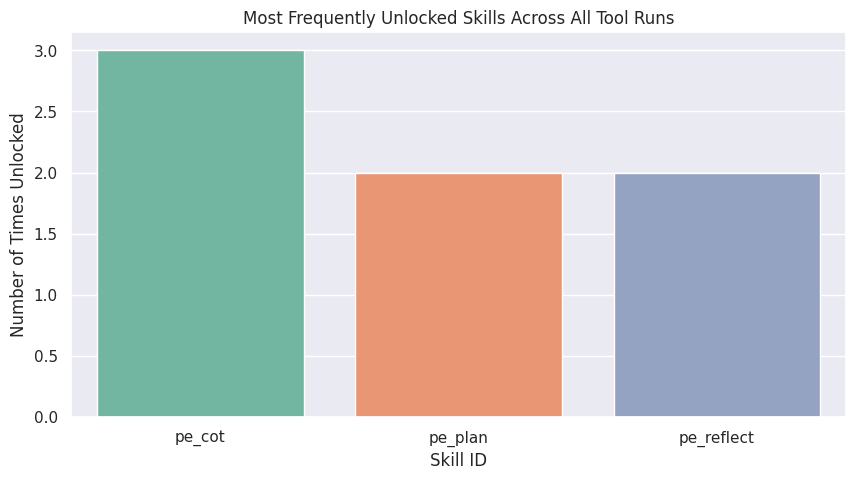

,skill,reason
0,pe_cot,Chain-of-thought (CoT) is a fundamental reasoning technique that significantly improves accuracy across all categories. Unlocking it now will ensure better performance on the upcoming questions and help me reach the next Skill Point threshold safely.
3,pe_cot,"Unlocking Chain-of-Thought (pe_cot) will significantly improve reasoning accuracy for higher-level questions, which is worth the 1 SP investment early on."
6,pe_cot,"Unlocking the Chain-of-Thought (pe_cot) skill will improve reasoning and accuracy for higher-level questions, which is essential for accumulating XP more safely."
1,pe_plan,"Unlocking pe_plan is a priority as it grants both a planning block and a reflection call, significantly increasing accuracy and providing a safety net for difficult questions."
4,pe_plan,"Unlocking 'pe_plan' adds a planning block and a reflection phase (an additional LLM call), which significantly increases the reliability of my answers and provides a safety net for higher-level challenges."
2,pe_reflect,"I have 1 Skill Point and pe_reflect is a high-priority skill. It provides a dedicated reflection call to review and correct my answer, which is vital for maintaining HP and ensuring XP gain on higher-level questions."
5,pe_reflect,"Unlocking 'pe_reflect' is a priority as it provides a safety net for answering questions by allowing a dedicated self-correction step, which is crucial for preserving HP and ensuring XP gain."


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

pd.set_option('display.max_colwidth', None)
sns.set_theme()

with open('../scripts/parsed_task2.json', 'r') as f:
    tool_data = json.load(f)

df_tools = pd.DataFrame(tool_data)
if df_tools.empty:
    print("No tool unlocks found.")
else:
    # 2c: Most frequently unlocked
    skill_counts = df_tools['skill'].value_counts().reset_index()
    skill_counts.columns = ['Skill', 'Unlock Count']
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=skill_counts, x='Skill', y='Unlock Count', palette='Set2')
    plt.title('Most Frequently Unlocked Skills Across All Tool Runs')
    plt.xlabel('Skill ID')
    plt.ylabel('Number of Times Unlocked')
    plt.show()
    
    # 2a: Aggregate table of reasons
    display(HTML("<h3>Aggregate Reasons for Unlocking Each Skill</h3>"))
    aggregate_reasons = df_tools[['skill', 'reason']].sort_values(by='skill')
    display(aggregate_reasons)

## 2.2 Inspection View: Did the LLM lie? (Tasks 2b, 2d)

For each skill unlock event, we present a clean view showing the context the LLM had available (the 4 nearby door choices), the reason it gave for unlocking a skill, and what the LLM *actually* did immediately after unlocking the skill. 
This allows manual inspection to see if its explicitly stated strategy aligned with its subsequent action.

In [3]:
html_str = ""
for index, row in df_tools.iterrows():
    doors_list = "".join([f"<li><b>Door {d['door']}</b>: Level {d['level']} - {d['category']}</li>" for d in row['doors']])
    
    html_str += f"""
    <div style='border: 1px solid #ccc; padding: 15px; margin-bottom: 20px; border-radius: 5px; background-color: #f9f9f9;'>
        <h4 style='margin-top: 0;'>Seed: {row['seed']} | Chamber (Turn): {row['chamber']}</h4>
        <p><b>Skill Unlocked:</b> <code style='font-size: 14px; color: #d03050;'>{row['skill']}</code></p>
        <p><b>LLM's Stated Reason:</b><br><i style='color: #444;'>"{row['reason']}"</i></p>
        <div>
            <b>Nearby Question Categories (Available Options):</b>
            <ul style='margin-top: 5px; margin-bottom: 10px;'>
                {doors_list}
            </ul>
        </div>
        <p><b>Action Immediately After Unlock:</b> <span style='background-color: #d1ecf1; padding: 3px 8px; border-radius: 3px;'>{row['action_after']}</span></p>
    </div>
    """

display(HTML(html_str))

/tmp/ipykernel_9201/1985446815.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


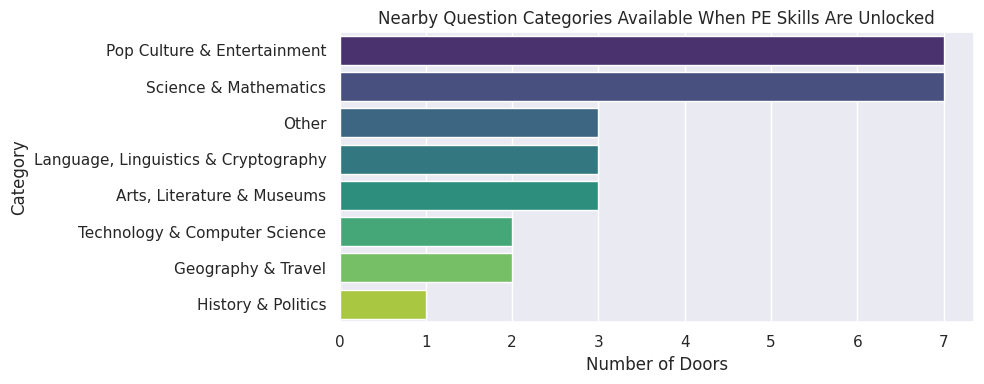

/tmp/ipykernel_9201/1985446815.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


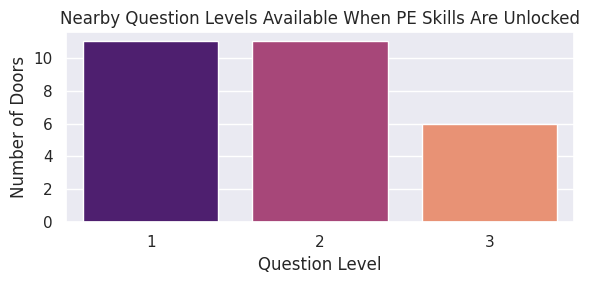

In [5]:
# Extract categories and levels grouped by skill prefix
prefix_data = {}

for index, row in df_tools.iterrows():
    skill = row['skill']
    prefix = skill.split('_')[0].upper() # e.g. PE, CTX, TOOL
    
    if prefix not in prefix_data:
        prefix_data[prefix] = {'categories': [], 'levels': []}
        
    for d in row['doors']:
        prefix_data[prefix]['categories'].append(d['category'])
        prefix_data[prefix]['levels'].append(d['level'])

# Generate graphs for each distinct skill prefix
for prefix, data in prefix_data.items():
    cat_df = pd.DataFrame(data['categories'], columns=['Category'])
    lvl_df = pd.DataFrame(data['levels'], columns=['Level'])
    
    display(HTML(f"<hr><h3>Skill Category: {prefix}</h3>"))
    
    if not cat_df.empty:
        # Graph 1: Categories
        plt.figure(figsize=(10, 4))
        sns.countplot(
            data=cat_df, 
            y='Category', 
            order=cat_df['Category'].value_counts().index, 
            palette='viridis'
        )
        plt.title(f'Nearby Question Categories Available When {prefix} Skills Are Unlocked')
        plt.xlabel('Number of Doors')
        plt.ylabel('Category')
        plt.tight_layout()
        plt.show()

    if not lvl_df.empty:
        # Graph 2: Levels
        plt.figure(figsize=(6, 3))
        sns.countplot(
            data=lvl_df, 
            x='Level', 
            palette='magma'
        )
        plt.title(f'Nearby Question Levels Available When {prefix} Skills Are Unlocked')
        plt.xlabel('Question Level')
        plt.ylabel('Number of Doors')
        plt.tight_layout()
        plt.show()